# Forest Disturbance Detection - Modular Training Pipeline

Clean demonstration of the modularized training workflow.
All code is now organized in the `disturbance_detection` package.

**Sections:**
1. Setup & Configuration
2. Data Loading & Preparation
3. Model Training
4. Evaluation & Visualization

In [1]:
import pandas as pd
import torch
import os

# Import from our modular package
from disturbance_detection import (
    Config, set_seed,
    prepare_data, print_split_balances, make_or_load_uid_splits,
    SmallUNet1D, FocalLoss,
    safe_to_device,
    train_and_select_best,
    final_eval_with_val_threshold,
    count_supervised_positives,
    plot_history, plot_precision_recall_curve, 
    plot_f1_vs_threshold, print_classification_report
)

print("All imports successful!")

All imports successful!


In [2]:
# Create configuration
config = Config()

# Set random seed for reproducibility
set_seed(config.seed)

# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Display key configuration
print(f"\nConfiguration:")
print(f"  Features: {config.features_mode} ({config.get_num_features()} features)")
print(f"  Window size: {config.window_size}")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Focal loss: alpha={config.focal_alpha}, gamma={config.focal_gamma}")

Random seed set to 42
Using device: cuda:0

Configuration:
  Features: bands (6 features)
  Window size: 5
  Batch size: 64
  Epochs: 30
  Learning rate: 0.0001
  Focal loss: alpha=0.5, gamma=1.9


In [3]:
# Load dataset
df = pd.read_csv(config.csv_path, index_col=0, sep=config.csv_separator)
print(f"Loaded {len(df)} samples")

# Create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)

# Filter doubtful samples (optional - from original notebook)
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
#df = df[~((df['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

print(f"After filtering: {len(df)} samples")
print(f"\nClass distribution:")
print(df['class_level1'].value_counts())

Loaded 567084 samples
After filtering: 524772 samples

Class distribution:
class_level1
treed          510211
disturbance      8711
non-treed        5850
Name: count, dtype: int64


In [4]:
# Prepare train/val/test splits and dataloaders
train_loader, val_loader, test_loader, n_features, features = prepare_data(df, config)

print(f"\nData preparation complete!")
print(f"Features used: {features}")
print(f"Number of features: {n_features}")
print(f"\nDataLoader sizes:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

[INFO] Loaded existing split file: /home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Data/new_class2_v5_seed42_uids_w5_v5_results.npz

Data preparation complete!
Features used: ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2']
Number of features: 6

DataLoader sizes:
  Train batches: 5006
  Val batches: 730
  Test batches: 1410


In [5]:
# Check class balance at supervised position
tr_pos, tr_tot, tr_rate = count_supervised_positives(train_loader, config.target_mode, device)
va_pos, va_tot, va_rate = count_supervised_positives(val_loader, config.target_mode, device)
te_pos, te_tot, te_rate = count_supervised_positives(test_loader, config.target_mode, device)

print(f"Class balance at target position ('{config.target_mode}'):")
print(f"  Train: {tr_pos}/{tr_tot} ({100*tr_rate:.3f}% positive)")
print(f"  Val:   {va_pos}/{va_tot} ({100*va_rate:.3f}% positive)")
print(f"  Test:  {te_pos}/{te_tot} ({100*te_rate:.3f}% positive)")

Class balance at target position ('last'):
  Train: 1336/320371 (0.417% positive)
  Val:   196/46693 (0.420% positive)
  Test:  354/90229 (0.392% positive)


In [6]:
# Initialize model
model = SmallUNet1D(
    in_channels=config.get_num_features(),
    base=config.base_channels,
    p_drop=config.dropout_rate,
    norm=config.norm_type,
    kernel_sizes_small=config.kernel_sizes_small,
    tdrop_rate=config.temporal_dropout_rate
)

# Move to device
model = safe_to_device(model, device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created: SmallUNet1D")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Model created: SmallUNet1D
  Total parameters: 56,689
  Trainable parameters: 56,689


In [7]:
# Create optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=config.betas,
    eps=config.eps
)

# Create loss function
loss_fn = FocalLoss(
    alpha=config.focal_alpha,
    gamma=config.focal_gamma,
    reduction=config.loss_reduction
)

print("Optimizer: AdamW")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print(f"\nLoss: FocalLoss")
print(f"  Alpha: {config.focal_alpha}")
print(f"  Gamma: {config.focal_gamma}")

Optimizer: AdamW
  Learning rate: 0.0001
  Weight decay: 0.01

Loss: FocalLoss
  Alpha: 0.5
  Gamma: 1.9


In [ ]:
# ============================================================
# Cell 9: Train Model (Full Supervision)
# ============================================================
#from disturbance_detection.training_full_supervision import train_and_select_best_full_supervision
#from disturbance_detection.training_full_supervision import train_model_full_supervision
from disturbance_detection.training_full_supervision import train_epoch_full_supervision
from disturbance_detection.training_full_supervision import validate_epoch_full_supervision

# Train with FULL supervision on all positions
print(f"\nStarting FULL SUPERVISION training for {config.num_epochs} epochs...")
print(f"Training on: ALL valid positions")
print(f"Validation on: Target position only ({config.target_mode})")
print(f"Model selection by: {config.select_by}")
print("-" * 80)


for epoch in range(config.num_epochs):
    print(f"\n--- Epoch {epoch+1} ---")
    train_loss, train_acc, train_f1_all, train_f1_target = train_epoch_full_supervision(
        model, train_loader, optimizer, device, loss_fn, config
    )
    val_loss, val_f1_all, val_f1_target, val_auprc = validate_epoch_full_supervision(
        model, val_loader, device, loss_fn, config
    )

    print(f"Train Loss: {train_loss:.4f} | Train F1(all): {train_f1_all:.4f} | Train F1(target): {train_f1_target:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val F1(all): {val_f1_all:.4f} | Val F1(target): {val_f1_target:.4f} | Val AUPRC: {val_auprc:.4f}")




'''print("-" * 80)
print(f"\nTraining complete!")
print(f"Best epoch: {best_info['best_epoch']}")
print(f"Best {best_info['select_by']}: {best_info['best_metric']:.4f}")
print(f"Checkpoint saved: {best_info['ckpt_path']}")'''


Starting FULL SUPERVISION training for 30 epochs...
Training on: ALL valid positions
Validation on: Target position only (last)
Model selection by: auprc
--------------------------------------------------------------------------------

--- Epoch 1 ---
Train Loss: 0.0033 | Train F1(all): 0.1905 | Train F1(target): 0.2845
Val Loss: 0.0013 | Val F1(all): 0.5539 | Val F1(target): 0.7379 | Val AUPRC: 0.7716

--- Epoch 2 ---
Train Loss: 0.0019 | Train F1(all): 0.5095 | Train F1(target): 0.5780
Val Loss: 0.0011 | Val F1(all): 0.6643 | Val F1(target): 0.7732 | Val AUPRC: 0.8129

--- Epoch 3 ---
Train Loss: 0.0017 | Train F1(all): 0.5668 | Train F1(target): 0.6340
Val Loss: 0.0010 | Val F1(all): 0.6872 | Val F1(target): 0.7868 | Val AUPRC: 0.8219

--- Epoch 4 ---
Train Loss: 0.0016 | Train F1(all): 0.5849 | Train F1(target): 0.6248
Val Loss: 0.0010 | Val F1(all): 0.6977 | Val F1(target): 0.7989 | Val AUPRC: 0.8374

--- Epoch 5 ---
Train Loss: 0.0015 | Train F1(all): 0.6115 | Train F1(target): 

NameError: name 'best_info' is not defined

In [9]:
from disturbance_detection.training_full_supervision import train_full_supervision_with_selection

# Train with best model selection
print(f"\nStarting training for {config.num_epochs} epochs...")
print(f"Target position: {config.target_mode}")
print(f"Model selection by: {config.select_by}")
print("-" * 80)

history, best_info = train_full_supervision_with_selection(
    model, train_loader, val_loader, optimizer, device, loss_fn, config
)

print("-" * 80)
print(f"\nTraining complete!")
print(f"Best epoch: {best_info['best_epoch']}")
print(f"Best {best_info['select_by']}: {best_info['best_metric']:.4f}")
print(f"Checkpoint saved: {best_info['ckpt_path']}")


Starting training for 30 epochs...
Target position: last
Model selection by: auprc
--------------------------------------------------------------------------------
Epoch 01 | TrainLoss 0.0013 | TrainF1(all) 0.6681 | TrainF1(target) 0.6992 | ValLoss 0.0008 | ValF1(all) 0.7618 | ValF1* 0.8090 | ValAUPRC 0.8606
--------------------------------------------------------------------------------

Training complete!
Best epoch: 1
Best auprc: 0.8606
Checkpoint saved: best_model.pt


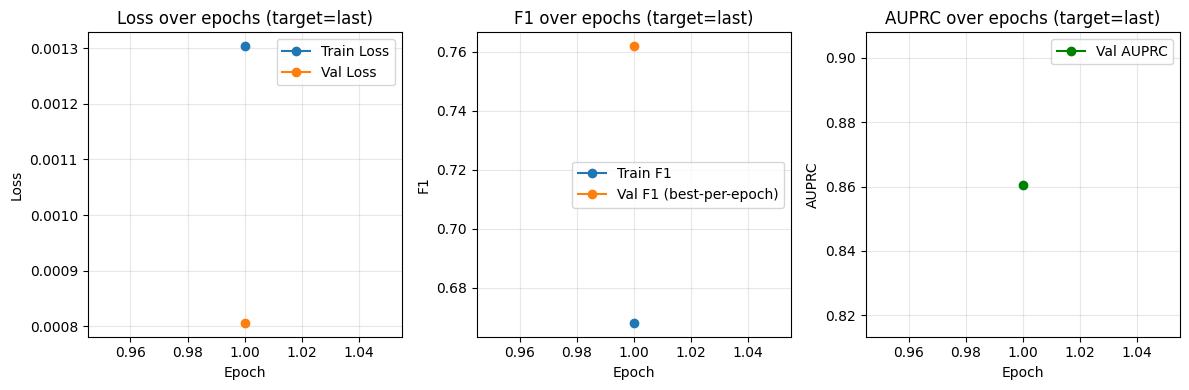

In [10]:
# Import the function with a different name
from disturbance_detection.evaluation import plot_history as plot_training_history

# Create a mapping for the plot function
plot_data = {
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_f1": history["train_f1_all"],  # Use f1_all as the main F1
    "val_f1": history["val_f1_all"],      # Use f1_all as the main F1
    "val_auprc": history["val_auprc"]
}

# Then plot
plot_training_history(plot_data, title_suffix=f" (target={config.target_mode})")

In [11]:
# Load best model and evaluate
print("Evaluating best model on test set...")
print("=" * 80)

best_thr, test_metrics = final_eval_with_val_threshold(
    model, device, config.checkpoint_path,
    val_loader, test_loader, 
    target_mode=config.target_mode
)

print("=" * 80)

Evaluating best model on test set...
Loaded best model from epoch 1.


/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/disturbance_detection/evaluation.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featur

[VAL] thr*=0.447 | F1*=0.809 | AUPRC=0.861
[TEST] thr=0.447 | P=0.793 R=0.780 F1=0.786 Acc=0.998 | AUPRC=0.838
Confusion matrix (TEST) [rows=true 0/1, cols=pred 0/1]:
 [[89803    72]
 [   78   276]]


In [12]:
from disturbance_detection.evaluation import collect_probs

# Collect test predictions
y_true_test, y_prob_test = collect_probs(model, test_loader, device, config.target_mode)

# Print detailed classification report
print_classification_report(
    y_true_test, y_prob_test, best_thr,
    target_names=["Undisturbed (0)", "Disturbed (1)"]
)

Accuracy: 0.998

Classification Report:
                 precision    recall  f1-score   support

Undisturbed (0)      0.999     0.999     0.999     89875
  Disturbed (1)      0.793     0.780     0.786       354

       accuracy                          0.998     90229
      macro avg      0.896     0.889     0.893     90229
   weighted avg      0.998     0.998     0.998     90229



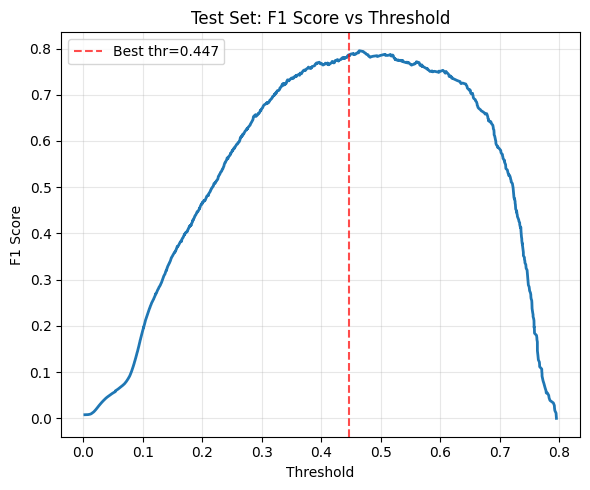

In [13]:
# F1 score as a function of threshold
plot_f1_vs_threshold(y_true_test, y_prob_test, best_thr, 
                     "Test Set: F1 Score vs Threshold")

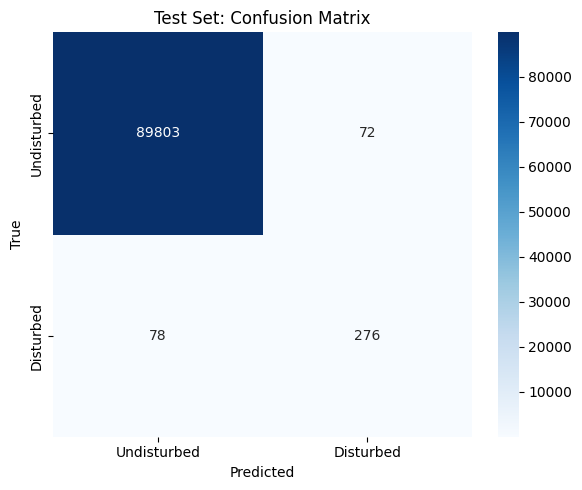

In [14]:
from disturbance_detection.evaluation import plot_confusion_matrix

# Plot confusion matrix
plot_confusion_matrix(test_metrics['cm'], 
                     labels=["Undisturbed", "Disturbed"],
                     title="Test Set: Confusion Matrix")